# SI618 Project 3 Machine Learning

### Project Title: Predicting Bike-Sharing Demand: A Weather-Driven Analysis for Capital Bikeshare

Fall24 SI618 Group 17

School of Information, University of Michigan

### Team Members
- Yidan Chang (yidanydc)
- Zhuxin Wu (zhuxinwu)
- Shangqing Wei (weishq)

## Target Description

**not finished yet**

## Data Preprocessing

### Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA


In [5]:
station_list = pd.read_csv("bikeshare/station_list.csv")
weather = pd.read_csv("bikeshare/weather.csv")
rent_detail= pd.read_csv('bikeshare/daily_rent_detail.csv')


### Data cleaning and handling of issues

#### Merging and Data Type Converting

In the third part of the project, we need to adjust the data instead of using the tables in the first two parts to some extent. 

In the data merging step, our work is mainly focus on:
- Instead of merging the weather data with the usage_frequeny data, we choose to merge it with the rent_detail data this time. This makes sure that the data we perform machine learning has enough columns of features.
- To minimize the computational complexity associated with year, we confine all of the rent detail data to the same year, rather than across years. Our new time span is 2023.1.1 to 2023.12.31. We use the rent detail data and the weather data in this time scale.
- We also want to remove some unnecessary columns, such as station information and the text description in the weather table, etc. In order for subsequent machine learning models to process the data faster and reduce the amount of computation, we use stations' codes instead of their names. Therefore we will also drop the stations' names in rent_detail table.


In [3]:
rent_detail_23 = rent_detail[(rent_detail['started_at'] >= '2023-01-01 00:00:00') & (rent_detail['started_at'] <= '2023-12-31 23:59:59')]
# rent_detail_23.to_csv('bikeshare/daily_rent_detail_2023.csv', index=False)

In [7]:
print(rent_detail_23.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4467334 entries, 0 to 4467333
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    float64
 6   end_station_name    object 
 7   end_station_id      float64
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(6), object(7)
memory usage: 443.1+ MB
None


In [8]:
rent_detail_23.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,65F0ACD101BF0D49,classic_bike,2023-01-04 19:34:07,2023-01-04 19:39:29,East Falls Church Metro / Sycamore St & 19th St N,31904.0,W Columbia St & N Washington St,32609.0,38.885321,-77.156427,38.885621,-77.166917,member
1,D75158CE73DC43F0,classic_bike,2023-01-27 15:26:38,2023-01-27 19:21:36,Carroll & Westmoreland Ave,32025.0,Fenton St & Ellsworth Dr,32036.0,38.975000,-77.011210,38.997033,-77.025608,member
2,33E85889625FF7CA,classic_bike,2023-01-05 20:44:38,2023-01-05 20:51:18,15th & L St NW,31276.0,Thomas Circle,31241.0,38.903649,-77.034918,38.905900,-77.032500,member
3,E1F055A1651F47A1,classic_bike,2023-01-03 17:45:14,2023-01-03 17:57:23,Hartland Rd & Harte Pl,32255.0,Merrifield Cinema & Merrifield Town Center,32235.0,38.878601,-77.222808,38.870093,-77.229970,member
4,88CC90CEEC298BAF,classic_bike,2023-01-03 05:18:46,2023-01-03 05:25:50,Merrifield Cinema & Merrifield Town Center,32235.0,Hartland Rd & Harte Pl,32255.0,38.870093,-77.229970,38.878601,-77.222808,member


In [9]:
rent_detail_23 = rent_detail_23.drop(["start_station_name", "end_station_name"], axis=1)

In [10]:
rent_detail_23["started_at"] = pd.to_datetime(rent_detail_23["started_at"])
rent_detail_23["ended_at"] = pd.to_datetime(rent_detail_23["ended_at"])
rent_detail_23["start_station_id"] = pd.to_numeric(
    rent_detail_23["start_station_id"], errors="coerce"
).astype("Int64")
rent_detail_23["end_station_id"] = pd.to_numeric(
    rent_detail_23["end_station_id"], errors="coerce"
).astype("Int64")


In [11]:
weather_23 = weather[
    (weather["datetime"] >= "2023-01-01")
    & (weather["datetime"] <= "2023-12-31 23:59:59")
]

In [12]:
print(weather_23.info())

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 975 to 1339
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              365 non-null    object 
 1   datetime          365 non-null    object 
 2   tempmax           365 non-null    float64
 3   tempmin           365 non-null    float64
 4   temp              365 non-null    float64
 5   feelslikemax      365 non-null    float64
 6   feelslikemin      365 non-null    float64
 7   feelslike         365 non-null    float64
 8   dew               365 non-null    float64
 9   humidity          365 non-null    float64
 10  precip            365 non-null    float64
 11  precipprob        365 non-null    int64  
 12  precipcover       365 non-null    float64
 13  preciptype        179 non-null    object 
 14  snow              365 non-null    float64
 15  snowdepth         365 non-null    float64
 16  windgust          365 non-null    float64
 17 

In [13]:
weather_23.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
975,"Washington,DC,USA",2023-01-01,16.3,6.4,11.0,16.3,5.4,10.7,7.9,82.2,...,8.7,4,10.0,2023-01-01T07:26:52,2023-01-01T16:56:42,0.32,"Rain, Partially cloudy",Clearing in the afternoon with morning rain.,rain,"KDCA,72405013743,72403793728,KADW,KDAA,AS365,7..."
976,"Washington,DC,USA",2023-01-02,17.2,4.4,10.5,17.2,2.4,10.1,6.8,79.3,...,5.7,4,10.0,2023-01-02T07:26:59,2023-01-02T16:57:31,0.35,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"KDCA,72405013743,72403793728,KADW,KDAA,AS365,7..."
977,"Washington,DC,USA",2023-01-03,20.0,10.1,15.2,20.0,10.1,15.2,11.3,78.5,...,3.4,2,10.0,2023-01-03T07:27:04,2023-01-03T16:58:22,0.39,Overcast,Cloudy skies throughout the day.,cloudy,"KDCA,72405013743,72403793728,KGAI,KADW,KDAA,AS..."
978,"Washington,DC,USA",2023-01-04,18.3,11.9,15.3,18.3,11.9,15.3,12.9,85.4,...,2.8,2,10.0,2023-01-04T07:27:07,2023-01-04T16:59:14,0.42,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"KDCA,72405013743,72403793728,KGAI,KADW,KDAA,AS..."
979,"Washington,DC,USA",2023-01-05,17.8,9.8,13.5,17.8,7.3,13.3,7.8,70.4,...,6.0,4,10.0,2023-01-05T07:27:08,2023-01-05T17:00:08,0.46,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"KDCA,72405013743,72403793728,KADW,KDAA,AS365,7..."


In [14]:
weather_23.loc[:, "datetime"] = pd.to_datetime(weather_23["datetime"]).dt.date

weather_23.loc[:, "sunrise"] = pd.to_datetime(weather_23["sunrise"], errors="coerce")
weather_23.loc[:, "sunset"] = pd.to_datetime(weather_23["sunset"], errors="coerce")

weather_23 = weather_23.drop(["name", "conditions", "description", "stations"], axis=1)

In [15]:
weather_23.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 975 to 1339
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          365 non-null    object 
 1   tempmax           365 non-null    float64
 2   tempmin           365 non-null    float64
 3   temp              365 non-null    float64
 4   feelslikemax      365 non-null    float64
 5   feelslikemin      365 non-null    float64
 6   feelslike         365 non-null    float64
 7   dew               365 non-null    float64
 8   humidity          365 non-null    float64
 9   precip            365 non-null    float64
 10  precipprob        365 non-null    int64  
 11  precipcover       365 non-null    float64
 12  preciptype        179 non-null    object 
 13  snow              365 non-null    float64
 14  snowdepth         365 non-null    float64
 15  windgust          365 non-null    float64
 16  windspeed         365 non-null    float64
 17 

In [16]:
rent_detail_23["started_day"] = rent_detail_23["started_at"].dt.date

data = rent_detail_23.merge(
    weather_23, left_on="started_day", right_on="datetime", how="left"
)
data = data.drop(["started_day", "datetime"], axis=1)

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4467334 entries, 0 to 4467333
Data columns (total 39 columns):
 #   Column            Dtype         
---  ------            -----         
 0   ride_id           object        
 1   rideable_type     object        
 2   started_at        datetime64[ns]
 3   ended_at          datetime64[ns]
 4   start_station_id  Int64         
 5   end_station_id    Int64         
 6   start_lat         float64       
 7   start_lng         float64       
 8   end_lat           float64       
 9   end_lng           float64       
 10  member_casual     object        
 11  tempmax           float64       
 12  tempmin           float64       
 13  temp              float64       
 14  feelslikemax      float64       
 15  feelslikemin      float64       
 16  feelslike         float64       
 17  dew               float64       
 18  humidity          float64       
 19  precip            float64       
 20  precipprob        int64         
 21  precipco

In [18]:
data.head()

,ride_id,rideable_type,started_at,ended_at,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,...,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,icon
0,65F0ACD101BF0D49,classic_bike,2023-01-04 19:34:07,2023-01-04 19:39:29,31904,32609,38.885321,-77.156427,38.885621,-77.166917,...,85.1,15.9,32.2,2.8,2,10.0,2023-01-04 07:27:07,2023-01-04 16:59:14,0.42,partly-cloudy-day
1,D75158CE73DC43F0,classic_bike,2023-01-27 15:26:38,2023-01-27 19:21:36,32025,32036,38.975000,-77.011210,38.997033,-77.025608,...,46.9,16.0,107.9,9.4,5,10.0,2023-01-27 07:18:40,2023-01-27 17:23:33,0.20,partly-cloudy-day
2,33E85889625FF7CA,classic_bike,2023-01-05 20:44:38,2023-01-05 20:51:18,31276,31241,38.903649,-77.034918,38.905900,-77.032500,...,75.8,15.9,71.1,6.0,4,10.0,2023-01-05 07:27:08,2023-01-05 17:00:08,0.46,partly-cloudy-day
3,E1F055A1651F47A1,classic_bike,2023-01-03 17:45:14,2023-01-03 17:57:23,32255,32235,38.878601,-77.222808,38.870093,-77.229970,...,90.8,15.6,38.6,3.4,2,10.0,2023-01-03 07:27:04,2023-01-03 16:58:22,0.39,cloudy
4,88CC90CEEC298BAF,classic_bike,2023-01-03 05:18:46,2023-01-03 05:25:50,32235,32255,38.870093,-77.229970,38.878601,-77.222808,...,90.8,15.6,38.6,3.4,2,10.0,2023-01-03 07:27:04,2023-01-03 16:58:22,0.39,cloudy


In [19]:
data.isna().sum()

ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_id     406630
end_station_id       432484
start_lat                 0
start_lng                 0
end_lat                5945
end_lng                5945
member_casual             0
tempmax                   0
tempmin                   0
temp                      0
feelslikemax              0
feelslikemin              0
feelslike                 0
dew                       0
humidity                  0
precip                    0
precipprob                0
precipcover               0
preciptype          2475415
snow                      0
snowdepth                 0
windgust                  0
windspeed                 0
winddir                   0
sealevelpressure          0
cloudcover                0
visibility                0
solarradiation            0
solarenergy               0
uvindex                   0
severerisk                0
sunrise             

#### Null Values

- Since we want to cluster the start station of each rent record, we drop the data where the start station is null. 
- For records with null end station information, we chose to retain them and fill these null values with their start station's code.
- For data that have null values in weather information, according to the original data description, we can find that all the dates with missing preciptype are not rainy, so we directly use "not rain" to fill in the null value.


In [20]:
data = data.dropna(subset="start_station_id")

In [21]:
data["end_station_id"] = data["end_station_id"].fillna(data["start_station_id"])
data["end_lat"] = data["end_lat"].fillna(data["start_lat"])
data["end_lng"] = data["end_lng"].fillna(data["start_lng"])

In [22]:
data["preciptype"] = data["preciptype"].fillna("Not Rain")

In [23]:
data.isna().sum()

ride_id             0
rideable_type       0
started_at          0
ended_at            0
start_station_id    0
end_station_id      0
start_lat           0
start_lng           0
end_lat             0
end_lng             0
member_casual       0
tempmax             0
tempmin             0
temp                0
feelslikemax        0
feelslikemin        0
feelslike           0
dew                 0
humidity            0
precip              0
precipprob          0
precipcover         0
preciptype          0
snow                0
snowdepth           0
windgust            0
windspeed           0
winddir             0
sealevelpressure    0
cloudcover          0
visibility          0
solarradiation      0
solarenergy         0
uvindex             0
severerisk          0
sunrise             0
sunset              0
moonphase           0
icon                0
dtype: int64

#### Outlier

It is possible that some of the outliers may be present in our data (even if we didn't fully account for them in our first assignment), so we need to address these possible issues. Potential problems in our data may include:

- The time of the dropoff is earlier than the time of the pickup. These data are considered to be incorrect. Here we want to jop them.
- Numeric value anomaly. This may include climate data anomalies such as excessive temperatures or precipitation values. It may also include latitude and longitude data or station id data anomalies. We are not sure if this problem exists in our data, so we may describe columns where the data type is numeric.
- We may have duplicate records in our data. If two records have the same ride_id, we consider them to be anomalous duplicates and need to be deleted.


In [24]:
invalid_count = (rent_detail_23["ended_at"] < rent_detail_23["started_at"]).sum()
print(f"Number of rows where ended_at < started_at: {invalid_count}")


Number of rows where ended_at < started_at: 615


In [25]:
data = data.loc[data["ended_at"] >= data["started_at"], :]

In [26]:
numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns
print(numeric_cols)

Index(['start_station_id', 'end_station_id', 'start_lat', 'start_lng',
       'end_lat', 'end_lng', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'moonphase'],
      dtype='object')


In [27]:
data[numeric_cols].describe()

,start_station_id,end_station_id,start_lat,start_lng,end_lat,end_lng,tempmax,tempmin,temp,feelslikemax,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase
count,4060580.0,4060580.0,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,...,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06,4.060580e+06
mean,31373.864042,31375.416839,3.890296e+01,-7.703240e+01,3.890201e+01,-7.703205e+01,2.276410e+01,1.316809e+01,1.772133e+01,2.308624e+01,...,2.313072e+01,1.997372e+02,1.016313e+03,6.185697e+01,1.534168e+01,1.476480e+02,1.276161e+01,6.518676e+00,1.476582e+01,4.846858e-01
std,280.686356,282.867277,2.628016e-02,3.420685e-02,2.614504e-02,3.407513e-02,7.762391e+00,7.476432e+00,7.387763e+00,8.785323e+00,...,7.644239e+00,1.038572e+02,6.770336e+00,2.344634e+01,1.586682e+00,5.936925e+01,5.126304e+00,2.292517e+00,1.212265e+01,2.889629e-01
min,30200.0,30200.0,3.878255e+01,-7.738259e+01,3.870000e+01,-7.752000e+01,-1.000000e-01,-8.400000e+00,-4.200000e+00,-5.000000e+00,...,9.100000e+00,3.000000e-01,9.958000e+02,1.000000e+00,4.800000e+00,8.400000e+00,7.000000e-01,0.000000e+00,1.000000e+01,0.000000e+00
25%,31210.0,31213.0,3.889054e+01,-7.704459e+01,3.889050e+01,-7.704460e+01,1.660000e+01,7.000000e+00,1.190000e+01,1.660000e+01,...,1.760000e+01,1.227000e+02,1.011300e+03,4.660000e+01,1.550000e+01,1.045000e+02,9.000000e+00,5.000000e+00,1.000000e+01,2.300000e-01
50%,31281.0,31281.0,3.890276e+01,-7.703169e+01,3.890227e+01,-7.703023e+01,2.430000e+01,1.410000e+01,1.900000e+01,2.430000e+01,...,2.160000e+01,1.962000e+02,1.015900e+03,6.500000e+01,1.600000e+01,1.520000e+02,1.320000e+01,7.000000e+00,1.000000e+01,5.000000e-01
75%,31609.0,31611.0,3.891360e+01,-7.701367e+01,3.891264e+01,-7.701246e+01,2.930000e+01,1.970000e+01,2.400000e+01,2.920000e+01,...,2.600000e+01,3.033000e+02,1.021100e+03,8.010000e+01,1.600000e+01,2.003000e+02,1.730000e+01,8.000000e+00,1.000000e+01,7.500000e-01
max,33200.0,33200.0,3.912586e+01,-7.682554e+01,3.917000e+01,-7.682554e+01,3.650000e+01,2.590000e+01,3.000000e+01,4.210000e+01,...,5.810000e+01,3.574000e+02,1.038600e+03,1.000000e+02,1.600000e+01,2.625000e+02,2.270000e+01,1.000000e+01,6.000000e+01,9.800000e-01


We can notice that there are no outliers in our numeric data and we don't need to remove some records.

In [28]:
data = data.drop_duplicates(subset=["ride_id"])

#### Group By Station and Datetime

Our goal is to cluster the station data, so we perform a groupby operation on each station's records in this step. It should be noted that we choose the start station for this task and we also split the start time into month and day in this step.

When doing group by, we follow these ideas for some columns: 

- For the ride-related categorical data (rideable_type and member_casual), we count the number of occurrences of each category in all records at each station each day.
- For ride time, ride distance, and all weather-related numeric data, we record their average values as the corresponding attributes for the day of the station.
- Some of the categorical columns in the weather data are not treated specifically as they do not change in the same day.



In [29]:
data["month"] = data["started_at"].dt.month

data["day"] = data["started_at"].dt.day

data["ride_duration"] = (
    (data["ended_at"] - data["started_at"]).dt.total_seconds().astype(int)
)

data["ride_distance"] = (
    (data["end_lat"] - data["start_lat"]) ** 2
    + (data["end_lng"] - data["start_lng"]) ** 2
) ** 0.5

In [30]:
data.drop(
    ["started_at", "ended_at", "end_station_id", "end_lat", "end_lng"],
    axis=1,
    inplace=True,
)

In [31]:
grouped_data = (
    data.groupby(["month", "day", "start_station_id"])
    .agg(
        ride_count=("ride_id", "count"),
        start_lat=("start_lat", "mean"),
        start_lng=("start_lng", "mean"),
        classic_bike=("rideable_type", lambda x: (x == "classic_bike").sum()),
        docked_bike=("rideable_type", lambda x: (x == "docked_bike").sum()),
        electric_bike=("rideable_type", lambda x: (x == "electric_bike").sum()),
        avg_distance=("ride_distance", "mean"),
        avg_duration=("ride_duration", "mean"),
        casual_count=("member_casual", lambda x: (x == "casual").sum()),
        member_count=("member_casual", lambda x: (x == "member").sum()),
        tempmax=("tempmax", "mean"),
        tempmin=("tempmin", "mean"),
        temp=("temp", "mean"),
        feelslikemax=("feelslikemax", "mean"),
        feelslikemin=("feelslikemin", "mean"),
        feelslike=("feelslike", "mean"),
        dew=("dew", "mean"),
        humidity=("humidity", "mean"),
        precip=("precip", "mean"),
        precipprob=("precipprob", "mean"),
        precipcover=("precipcover", "mean"),
        preciptype=("preciptype", lambda x: x.mode().iat[0]),
        snow=("snow", "mean"),
        snowdepth=("snowdepth", "mean"),
        windgust=("windgust", "mean"),
        windspeed=("windspeed", "mean"),
        winddir=("winddir", "mean"),
        sealevelpressure=("sealevelpressure", "mean"),
        cloudcover=("cloudcover", "mean"),
        visibility=("visibility", "mean"),
        solarradiation=("solarradiation", "mean"),
        solarenergy=("solarenergy", "mean"),
        uvindex=("uvindex", "mean"),
        severerisk=("severerisk", "mean"),
        sunrise=("sunrise", "mean"),
        sunset=("sunset", "mean"),
        moonphase=("moonphase", "mean"),
        icon=("icon", lambda x: x.mode().iat[0]),
    )
    .reset_index()
)

In [32]:
grouped_data_copy=grouped_data.copy()

In [44]:
grouped_data["sunrise"] = pd.to_datetime(grouped_data["sunrise"],errors="coerce")
grouped_data["sunset"] = pd.to_datetime(grouped_data["sunset"], errors="coerce")

In [34]:
grouped_data.head()

,month,day,start_station_id,ride_count,start_lat,start_lng,classic_bike,docked_bike,electric_bike,avg_distance,...,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,icon
0,1,1,31000,6,38.858971,-77.053230,6,0,0,0.019847,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain
1,1,1,31002,6,38.856425,-77.049232,6,0,0,0.016549,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain
2,1,1,31003,7,38.861056,-77.049417,4,3,0,0.005941,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000256,0.32,rain
3,1,1,31004,2,38.857866,-77.059490,2,0,0,0.016923,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain
4,1,1,31005,5,38.862303,-77.059936,3,2,0,0.021915,...,47.7,14.6,100.5,8.7,4.0,10.0,2023-01-01 07:26:52,2023-01-01 16:56:42.000000000,0.32,rain


In [45]:
grouped_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219449 entries, 0 to 219448
Data columns (total 41 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   month             219449 non-null  int64         
 1   day               219449 non-null  int64         
 2   start_station_id  219449 non-null  int64         
 3   ride_count        219449 non-null  int64         
 4   start_lat         219449 non-null  float64       
 5   start_lng         219449 non-null  float64       
 6   classic_bike      219449 non-null  int64         
 7   docked_bike       219449 non-null  int64         
 8   electric_bike     219449 non-null  int64         
 9   avg_distance      219449 non-null  float64       
 10  avg_duration      219449 non-null  float64       
 11  casual_count      219449 non-null  int64         
 12  member_count      219449 non-null  int64         
 13  tempmax           219449 non-null  float64       
 14  temp

### Feature scaling and normalization

In our analysis, we separate start_station_id and its attributes (start_lat, start_lng) into y, while keeping other features (e.g., weather features, ride time, etc.) in X. 

In [47]:
X=grouped_data.drop(["start_station_id",'start_lat','start_lng'], axis=1)
y=grouped_data[["start_station_id",'start_lat','start_lng']]

In [39]:
num_cols = X.select_dtypes(include=["float64", "int64", "int32"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns
time_col = X.select_dtypes(include=["datetime64[ns]"]).columns
print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print("time_col:", time_col)

num_cols: Index(['month', 'day', 'ride_count', 'classic_bike', 'docked_bike',
       'electric_bike', 'avg_distance', 'avg_duration', 'casual_count',
       'member_count', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'snow', 'snowdepth', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'moonphase'],
      dtype='object')
cat_cols: Index(['preciptype', 'sunrise', 'sunset', 'icon'], dtype='object')
time_col: Index([], dtype='object')


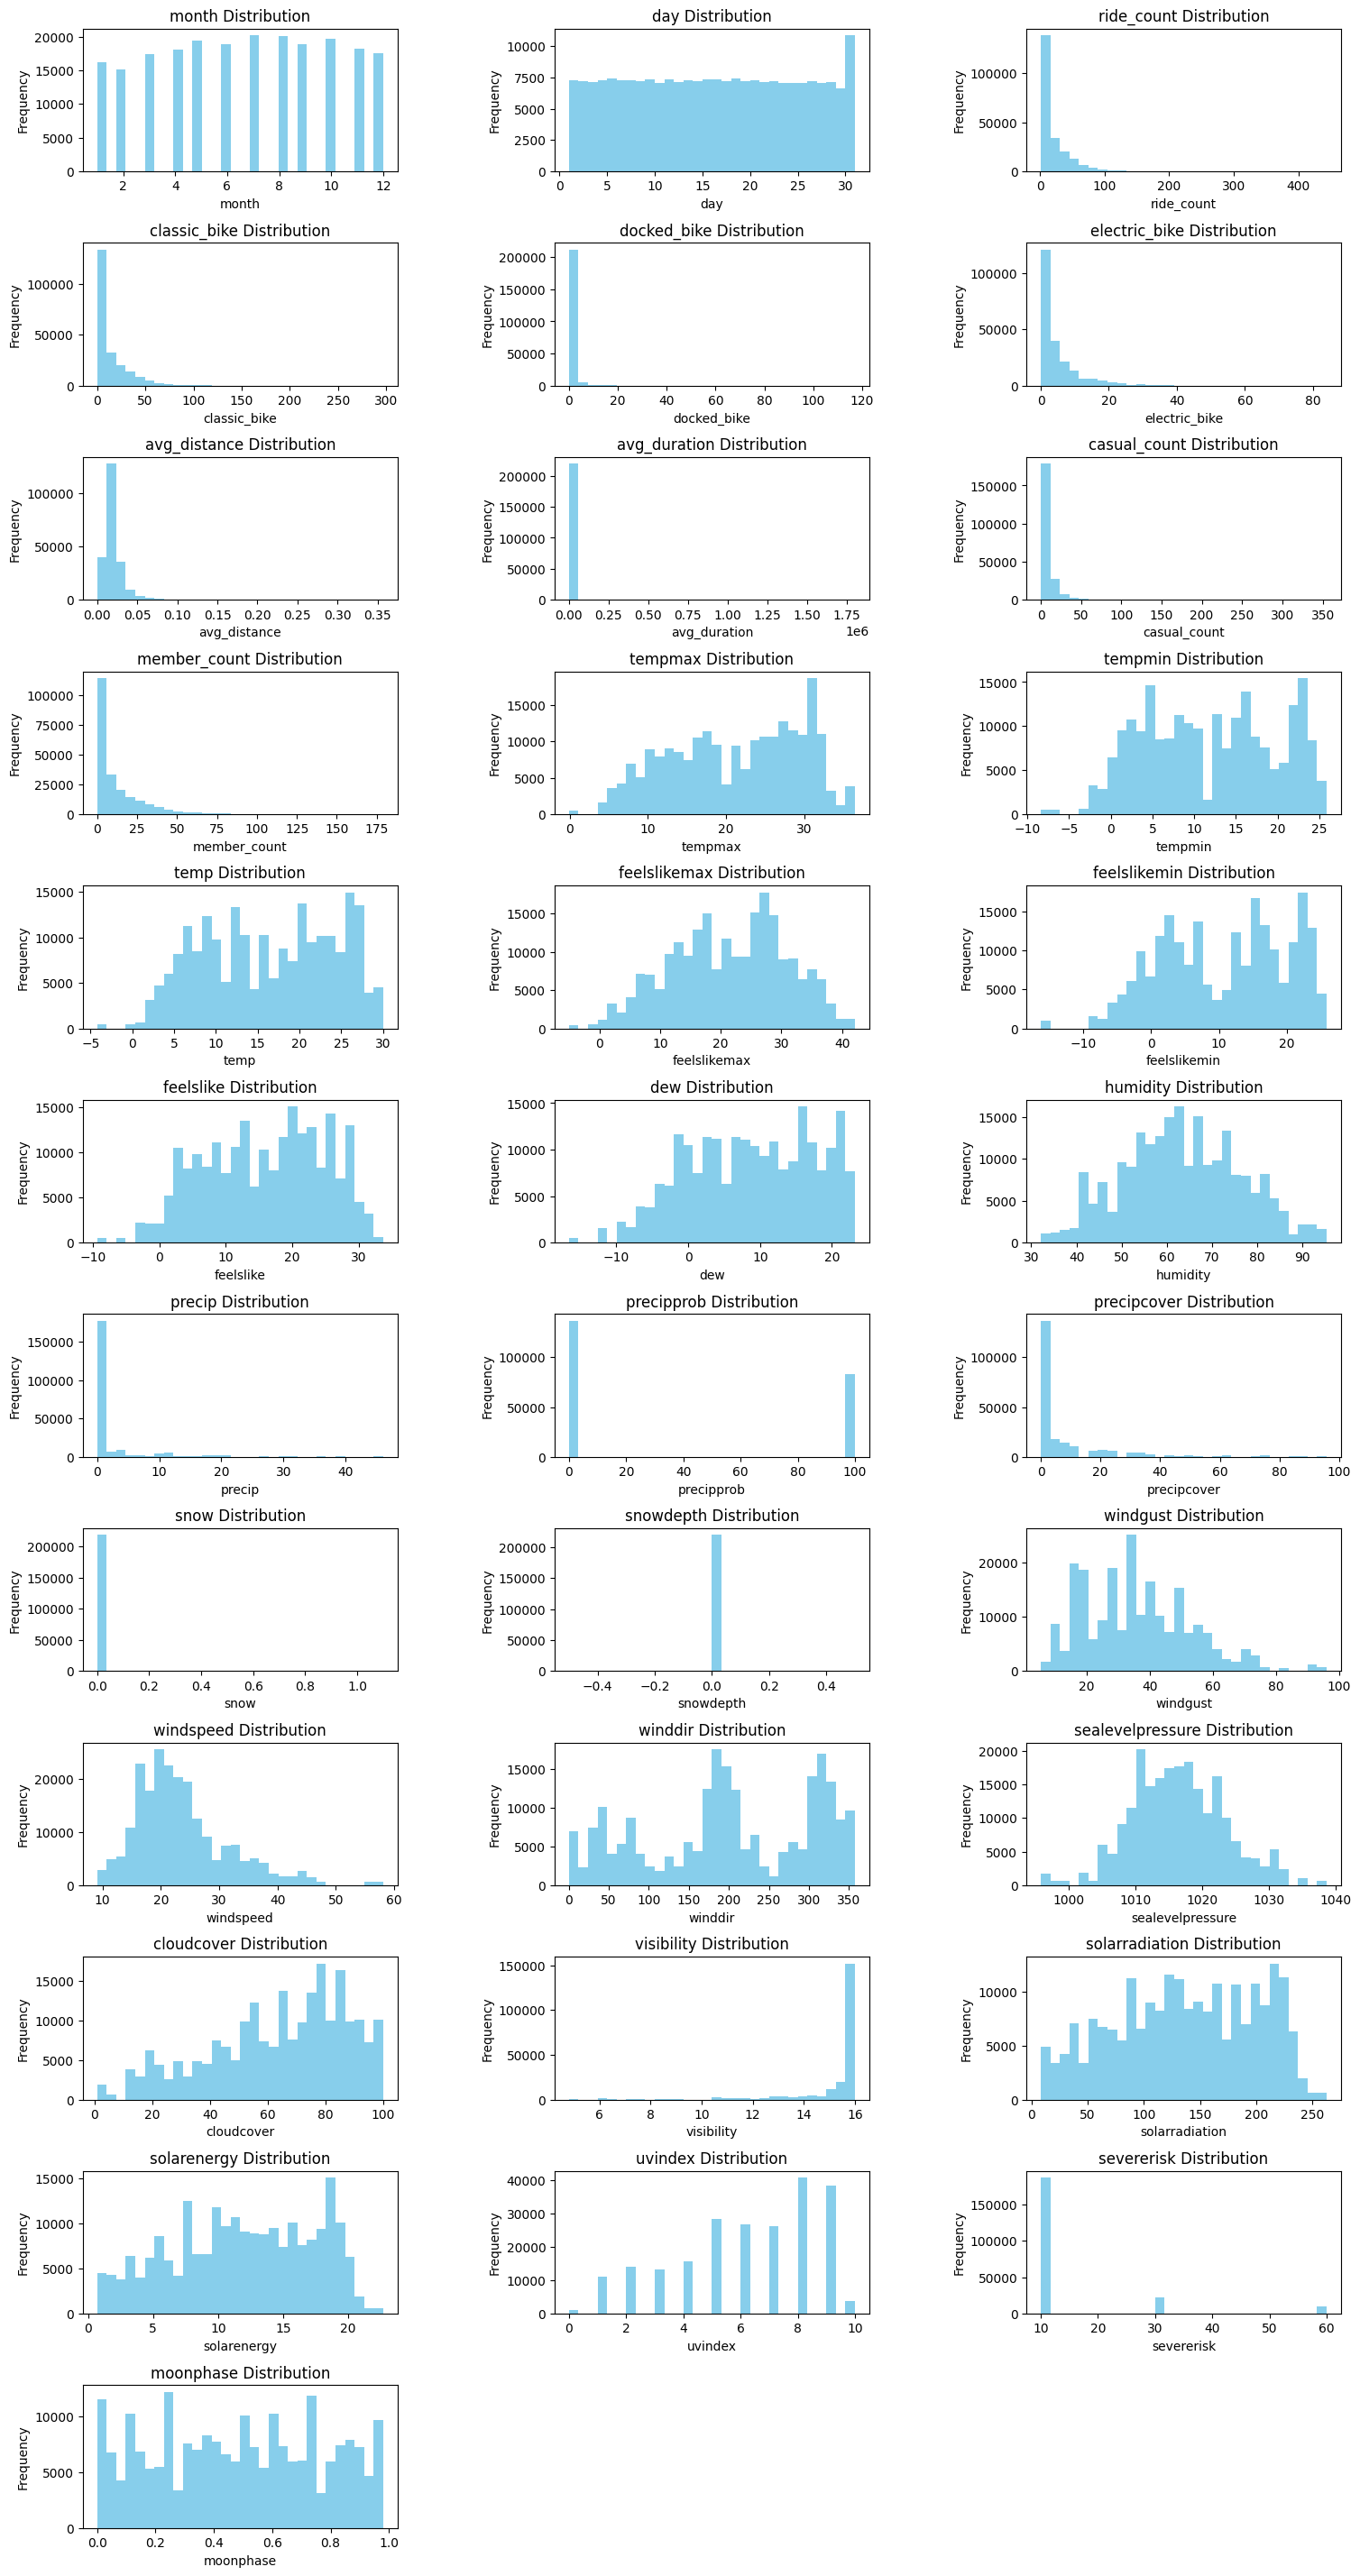

In [40]:
fig, axes = plt.subplots(
    len(num_cols) // 3 + (len(num_cols) % 3 > 0), 3, figsize=(18, 36), dpi=100
)
fig.subplots_adjust(hspace=0.5, wspace=0.5)


for i, ax in enumerate(axes.flatten()):
    if i < len(num_cols):
        ax.hist(X[num_cols[i]], bins=30, color="skyblue")
        ax.set_title(f"{num_cols[i]} Distribution")
        ax.set_xlabel(f"{num_cols[i]}")
        ax.set_ylabel("Frequency")
    else:
        ax.axis("off")

plt.show()

We transformed the data mainly based on the following ideas:

- Numeric Data: Our numeric data are not always normally distributed. If we use standard scale for all of them, it doesn't make sense for some columns. Therefore, we selectively perform operations such as standardization and normalization on some columns, mainly based on their distribution characteristics.
- Time Data: For time related attributes, we convert them to relative time, or extract cyclical characteristics, depending on their specific content.
- Categorical Data: We use One-Hot Encoding and converts categorical variables (e.g. preciptype, icon) to 0/1 encoding.

In [49]:
log_transformer = FunctionTransformer(np.log1p, validate=True)


def compute_day_length(X):
    if not {"sunrise", "sunset"}.issubset(X.columns):
        raise ValueError("Input DataFrame must contain 'sunrise' and 'sunset' columns.")
    return (X["sunset"] - X["sunrise"]).dt.total_seconds().to_numpy().reshape(-1, 1) / 3600

day_length_transformer = FunctionTransformer(compute_day_length, validate=False)


def cyclical_transform(X):
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    sin = np.sin(2 * np.pi * X)
    cos = np.cos(2 * np.pi * X)
    return np.hstack((sin, cos))

cyclical_transformer = FunctionTransformer(cyclical_transform, validate=True)

numeric_normal = [
    "tempmax",
    "tempmin",
    "temp",
    "feelslikemax",
    "feelslikemin",
    "feelslike",
    "dew",
    "humidity",
    'windgust',
    'windspeed',
    'winddir',
    'sealevelpressure',
    'cloudcover',
    'solarradiation',
    'solarenergy',
    'uvindex'
]
numeric_skewed = [
    "ride_count",
    "classic_bike",
    "docked_bike",
    "electric_bike",
    "avg_distance",
    "avg_duration",
    "casual_count",
    "member_count",
    "precip",
    "precipprob",
    "precipcover",
    "snow",
    "snowdepth",
    'visibility',
    'severerisk',
]
numeric_cyclical = ["month", "day", "moonphase"]

time_columns = ["sunrise", "sunset"]

categorical_cols = ["preciptype", "icon"]


preprocessor = ColumnTransformer(
    transformers=[
        ("normal", StandardScaler(), numeric_normal),
        (
            "skewed",
            Pipeline([("log", FunctionTransformer(np.log1p, validate=True)), ("scale", StandardScaler())]),
            numeric_skewed,
        ),
        ("cyclical", cyclical_transformer, numeric_cyclical),
        ("day_length", day_length_transformer, time_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ]
)


pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

transformed_X = pipeline.fit_transform(X)


In [50]:
transformed_X.shape

(219449, 49)

### Dimensionality reduction

We choose PCA to reduce the dimensionality of the data while retaining the majority of the variance.

At first we made a heatmap to see the correlation in our transformed data.

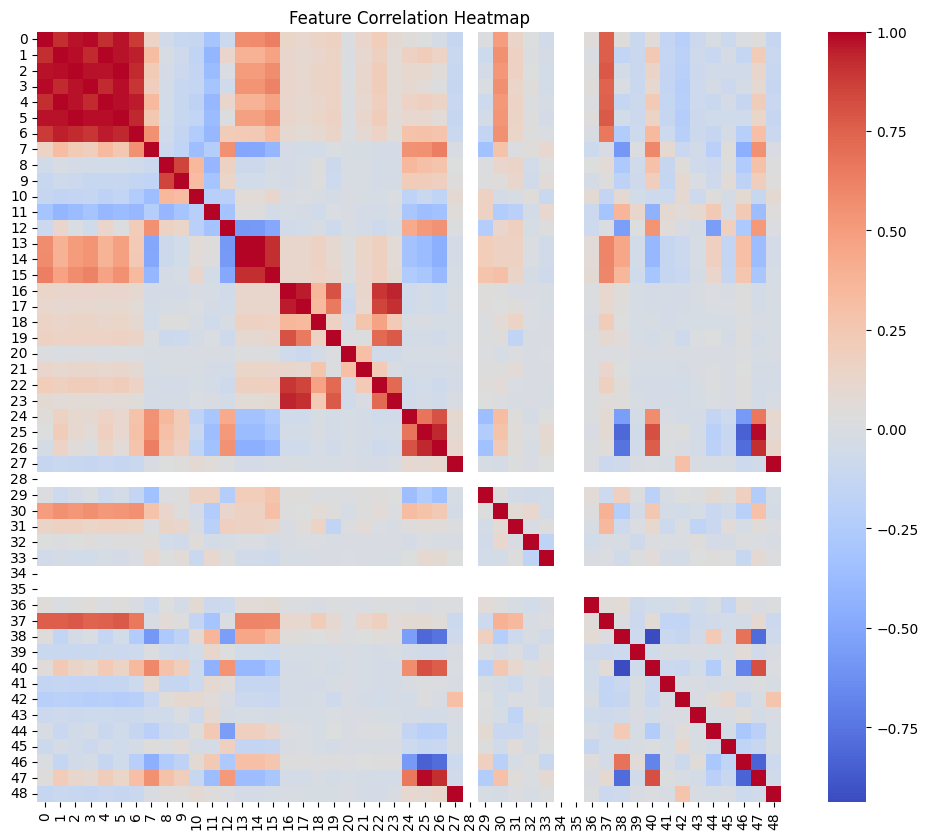

In [51]:

transformed_df = pd.DataFrame(transformed_X)
correlation_matrix = transformed_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In the correlation heatmap, there is a strong positive or negative correlation between some of the features, while the majority of the features have a weak correlation (close to 0, lighter color). This indicates that there are redundant features in the data, and the model can be optimized through feature selection or dimensionality reduction.

In [167]:

pca = PCA(n_components=8)
pca_X = pca.fit_transform(transformed_X)

print("Explained variance ratio:", pca.explained_variance_ratio_.sum())
print("Reduced data shape after PCA:", pca_X.shape)


Explained variance ratio: 0.803419943387371
Reduced data shape after PCA: (219449, 8)


We select 8 components and these components can explain 80% of the information, which seems enough for our analysis. This can balance computational efficiency with the preservation of information, aligning well with clustering or other unsupervised learning techniques planned for subsequent analysis.